In [55]:
# Do the components of a board game (complexity, number of players, playtime, number of components) affect the average user rating?

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [56]:
df = pd.read_csv(r"C:\Users\allis\Downloads\basic_data_2023.csv")


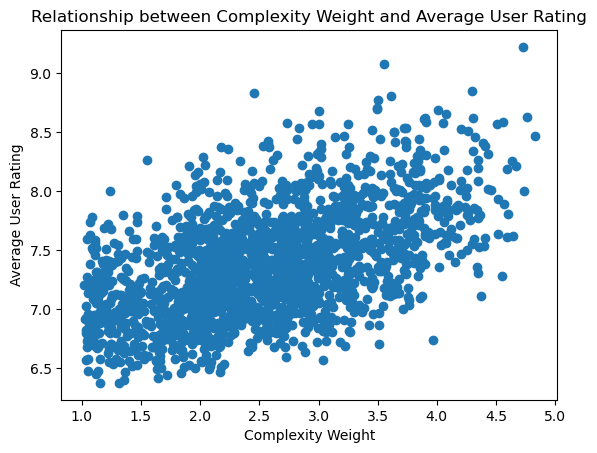

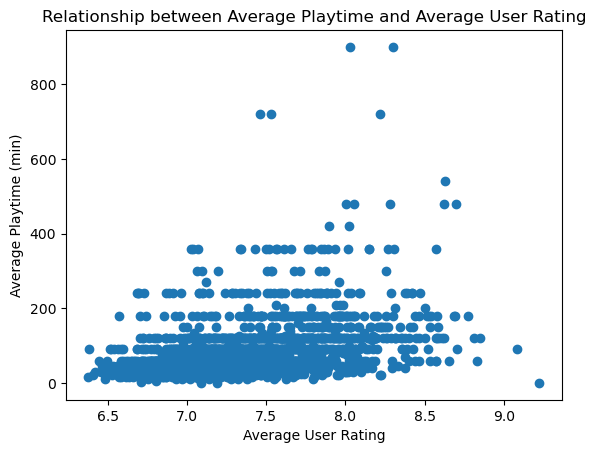

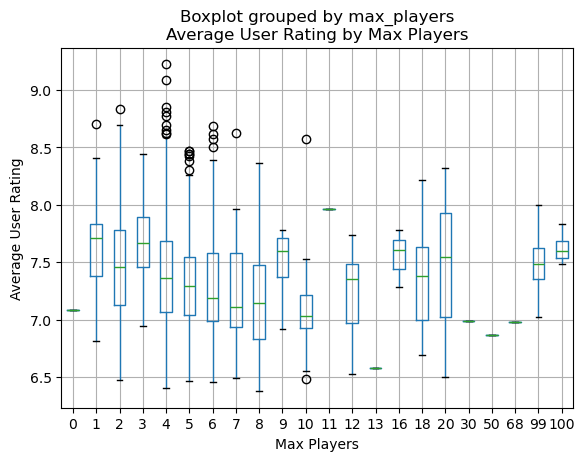

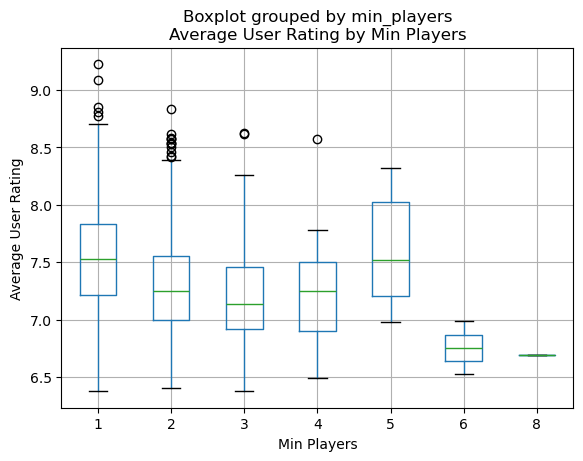

In [59]:
# visualizations to compare a few key variables:


# Includes ratings and rankings, number of players, playtime, year released, difficulty. 

# positive linear relationship
plt.figure()
plt.scatter(df["weight"], df["avg_rating"])
plt.xlabel("Complexity Weight")
plt.ylabel("Average User Rating")
plt.title("Relationship between Complexity Weight and Average User Rating")
plt.show()


# Creating list of average play time values without major outliers
average_time = []

for time in df["avg_time"]:
    if time < 999:
        average_time.append(time)
    else:
        average_time.append(None)
# slight positive linear relationship
plt.figure()
plt.scatter(df["avg_rating"], average_time)
plt.xlabel("Average User Rating")
plt.ylabel("Average Playtime (min)")
plt.title("Relationship between Average Playtime and Average User Rating")
plt.show()

# 3 to 5 is best
df.boxplot(column="avg_rating", by="max_players")
plt.xlabel("Max Players")
plt.ylabel("Average User Rating")
plt.title("Average User Rating by Max Players")
plt.show()

# lower the better but two is best
df.boxplot(column="avg_rating", by="min_players")
plt.xlabel("Min Players")
plt.ylabel("Average User Rating")
plt.title("Average User Rating by Min Players")
plt.show()






In [58]:
X = df[["complexity_weight", "max_players", "min_players", "avg_playtime_min", "num_components"]]
sm.add_constant(X)
y = df[["avg_user_rating"]]

model = sm.OLS(y,X).fit()
print(model.summary())

KeyError: "['complexity_weight', 'avg_playtime_min', 'num_components'] not in index"